In [ ]:
# Mini-Projet TMA — Stéganographie par LSB
# Institut Supérieur du Numérique (SupNum)

# Étudiant :24077
# Année :2025-2026
# Projet : L’Espion Fréquentiel

In [1]:
from google.colab import files
uploaded = files.upload()

Saving photo.jpg to photo.jpg


(np.float64(-0.5), np.float64(3412.5), np.float64(5119.5), np.float64(-0.5))

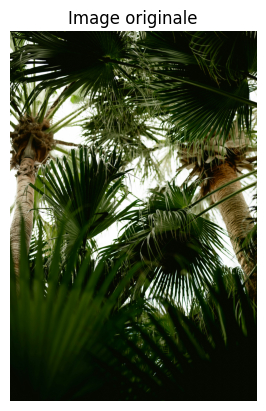

In [2]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load uploaded image
image = Image.open(list(uploaded.keys())[0]).convert("RGB")
img_array = np.array(image)

plt.title("Image originale")
plt.imshow(image)
plt.axis("off")

In [3]:
def text_to_binary(text):
    return ''.join(format(ord(char), '08b') for char in text)

def encode_message(img_array, message):
    binary_msg = text_to_binary(message) + '1111111111111110'
    flat_img = img_array.flatten()

    for i in range(len(binary_msg)):
        flat_img[i] = (flat_img[i] & 254) | int(binary_msg[i])

    return flat_img.reshape(img_array.shape)

(np.float64(-0.5), np.float64(3412.5), np.float64(5119.5), np.float64(-0.5))

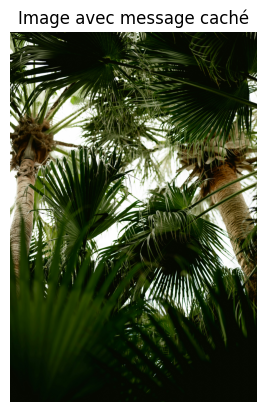

In [4]:
secret_message = "SupNum 2026 - Test OK"
encoded_img = encode_message(img_array.copy(), secret_message)

plt.title("Image avec message caché")
plt.imshow(encoded_img)
plt.axis("off")

In [5]:
from PIL import Image

stego_image = Image.fromarray(encoded_img.astype('uint8'))
stego_image.save("stego_image.png")

print("Image sauvegardée !")

Image sauvegardée !


In [6]:
files.download("stego_image.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
def binary_to_text(binary):
    chars = [binary[i:i+8] for i in range(0, len(binary), 8)]
    return ''.join(chr(int(char, 2)) for char in chars)

def decode_message(img_array):
    flat_img = img_array.flatten()
    binary_msg = ""

    for value in flat_img:
        binary_msg += str(value & 1)
        if binary_msg.endswith('1111111111111110'):
            break

    binary_msg = binary_msg[:-16]
    return binary_to_text(binary_msg)

decoded_message = decode_message(encoded_img)
print("Message extrait :", decoded_message)

Message extrait : SupNum 2026 - Test OK


## Analyse

### Principe
La stéganographie LSB consiste à modifier le bit de poids faible des pixels pour y insérer un message binaire.

### Résultat
L’image modifiée reste visuellement identique à l’originale, mais elle contient un message caché.

### Avantages
- Invisible à l’œil humain
- Simple à implémenter
- Rapide

### Limites
- Sensible à la compression JPEG
- Peut être détectée par analyse statistique

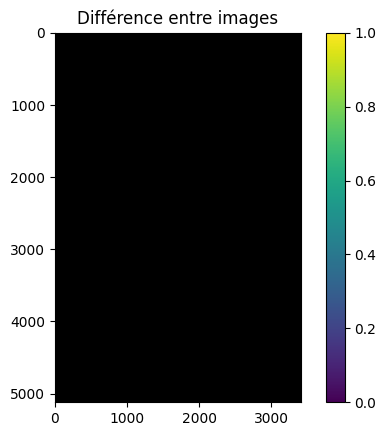

In [8]:
difference = np.abs(img_array.astype(int) - encoded_img.astype(int))
plt.imshow(difference)
plt.title("Différence entre images")
plt.colorbar()